
**Dataset Loading**



In [2]:
import pandas as pd

df = pd.read_csv("fetal_health.csv")
df.head()
df.info()
df.describe()
df['fetal_health'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   int64  
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   int64  
 8   mean_value_of_short_term_variability  

,count
fetal_health,
1,1655
2,295
3,176


**Data Prepration**

In [3]:
print(df.shape)
print(df.columns)
print(df.info())
df.describe()
df.isnull().sum()

(2126, 22)
Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 n

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


**Exploratory Data Analysis on dataset**

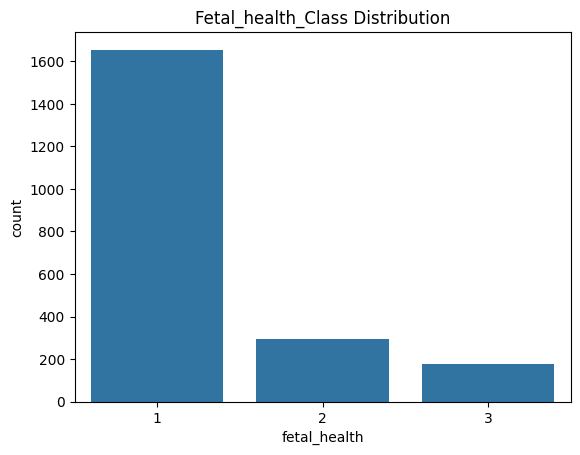

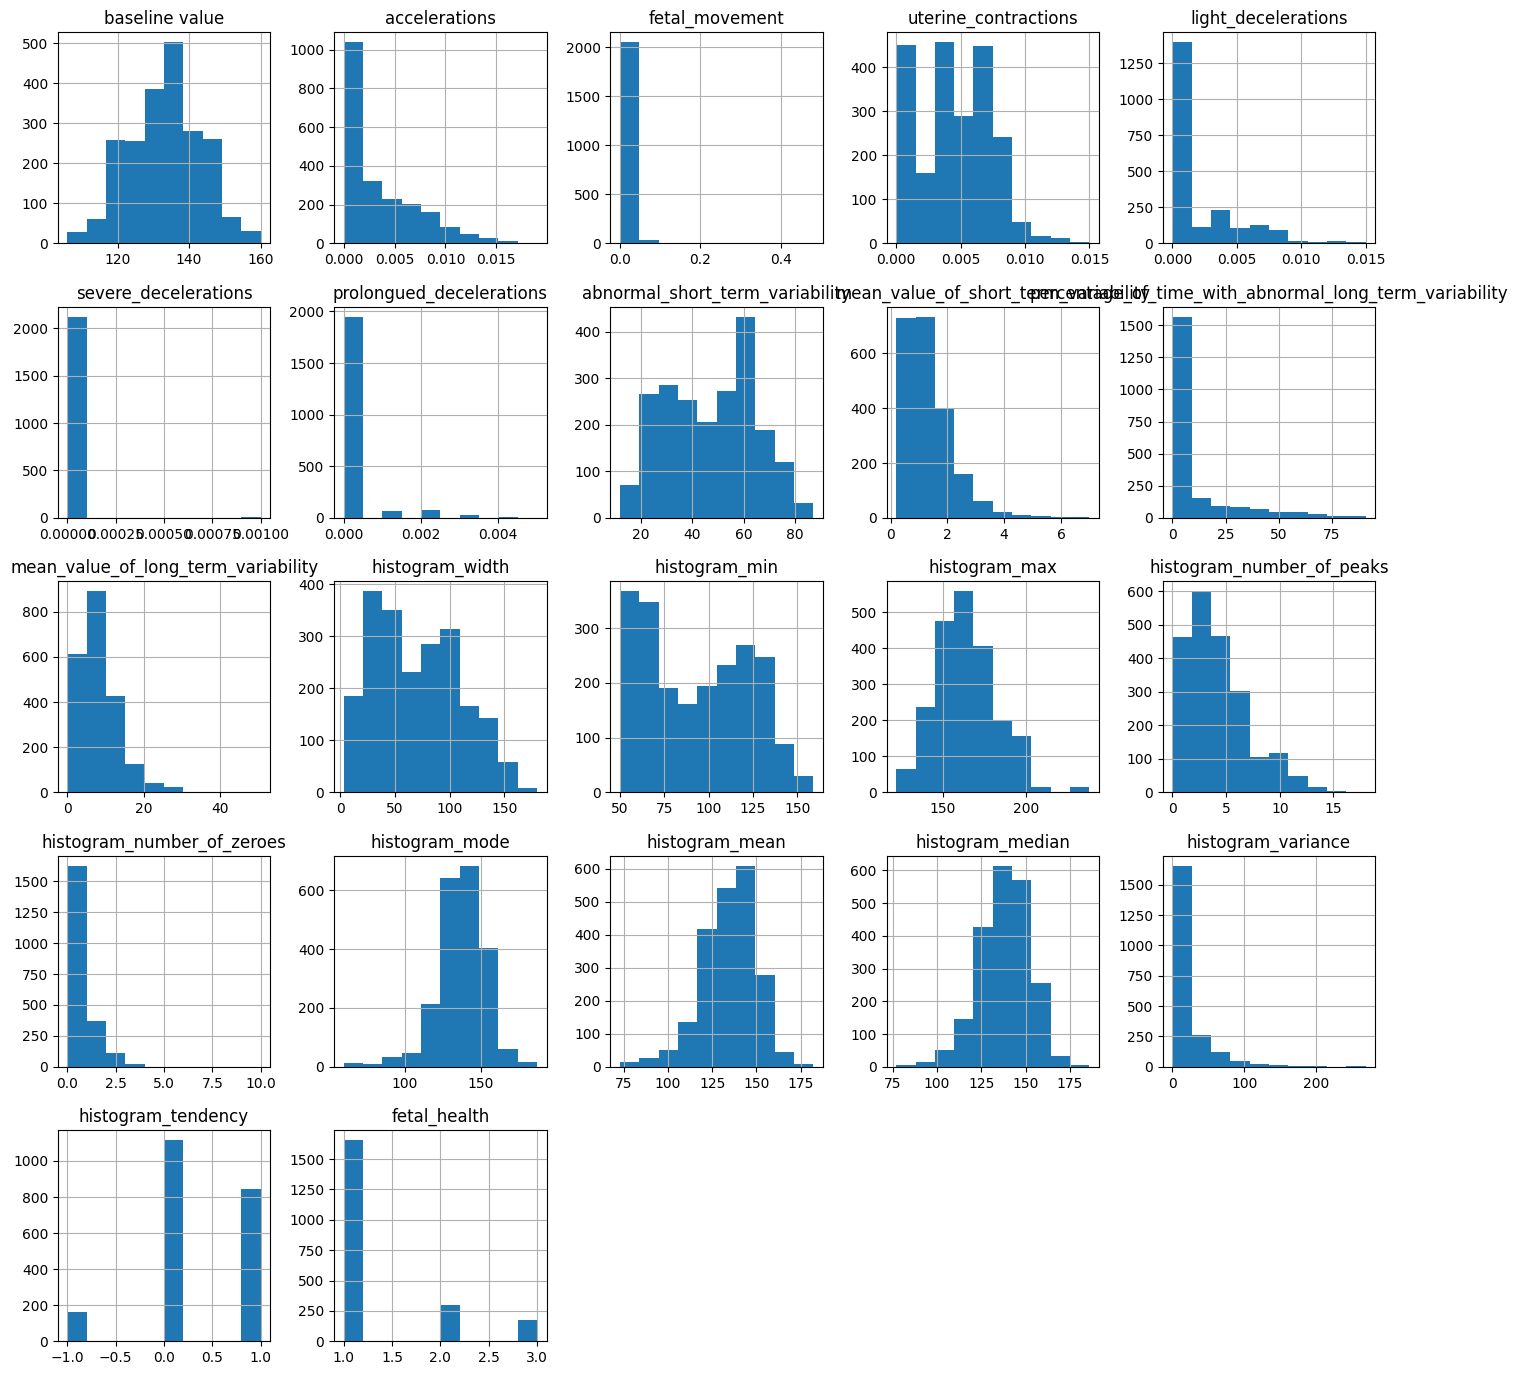

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fetal_health', data=df)
plt.title("Fetal_health_Class Distribution")
plt.show()
df.hist(figsize=(17,17),layout=(5,5), sharex=False)
plt.show()

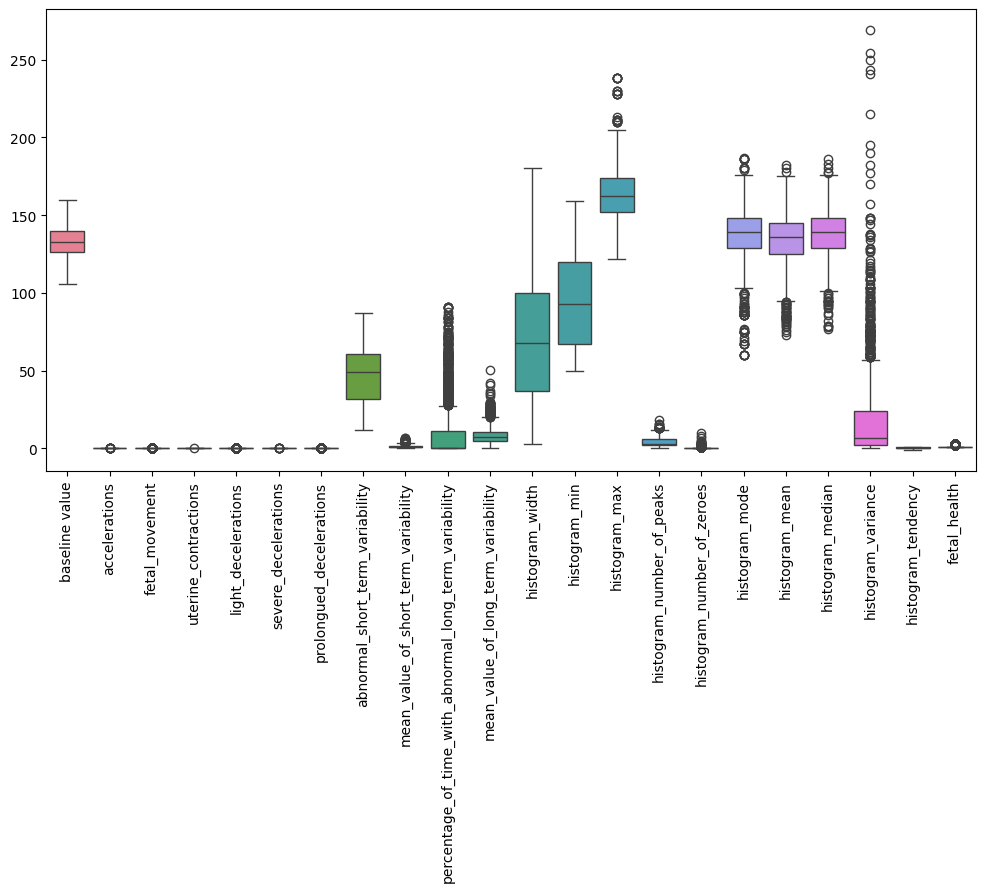

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

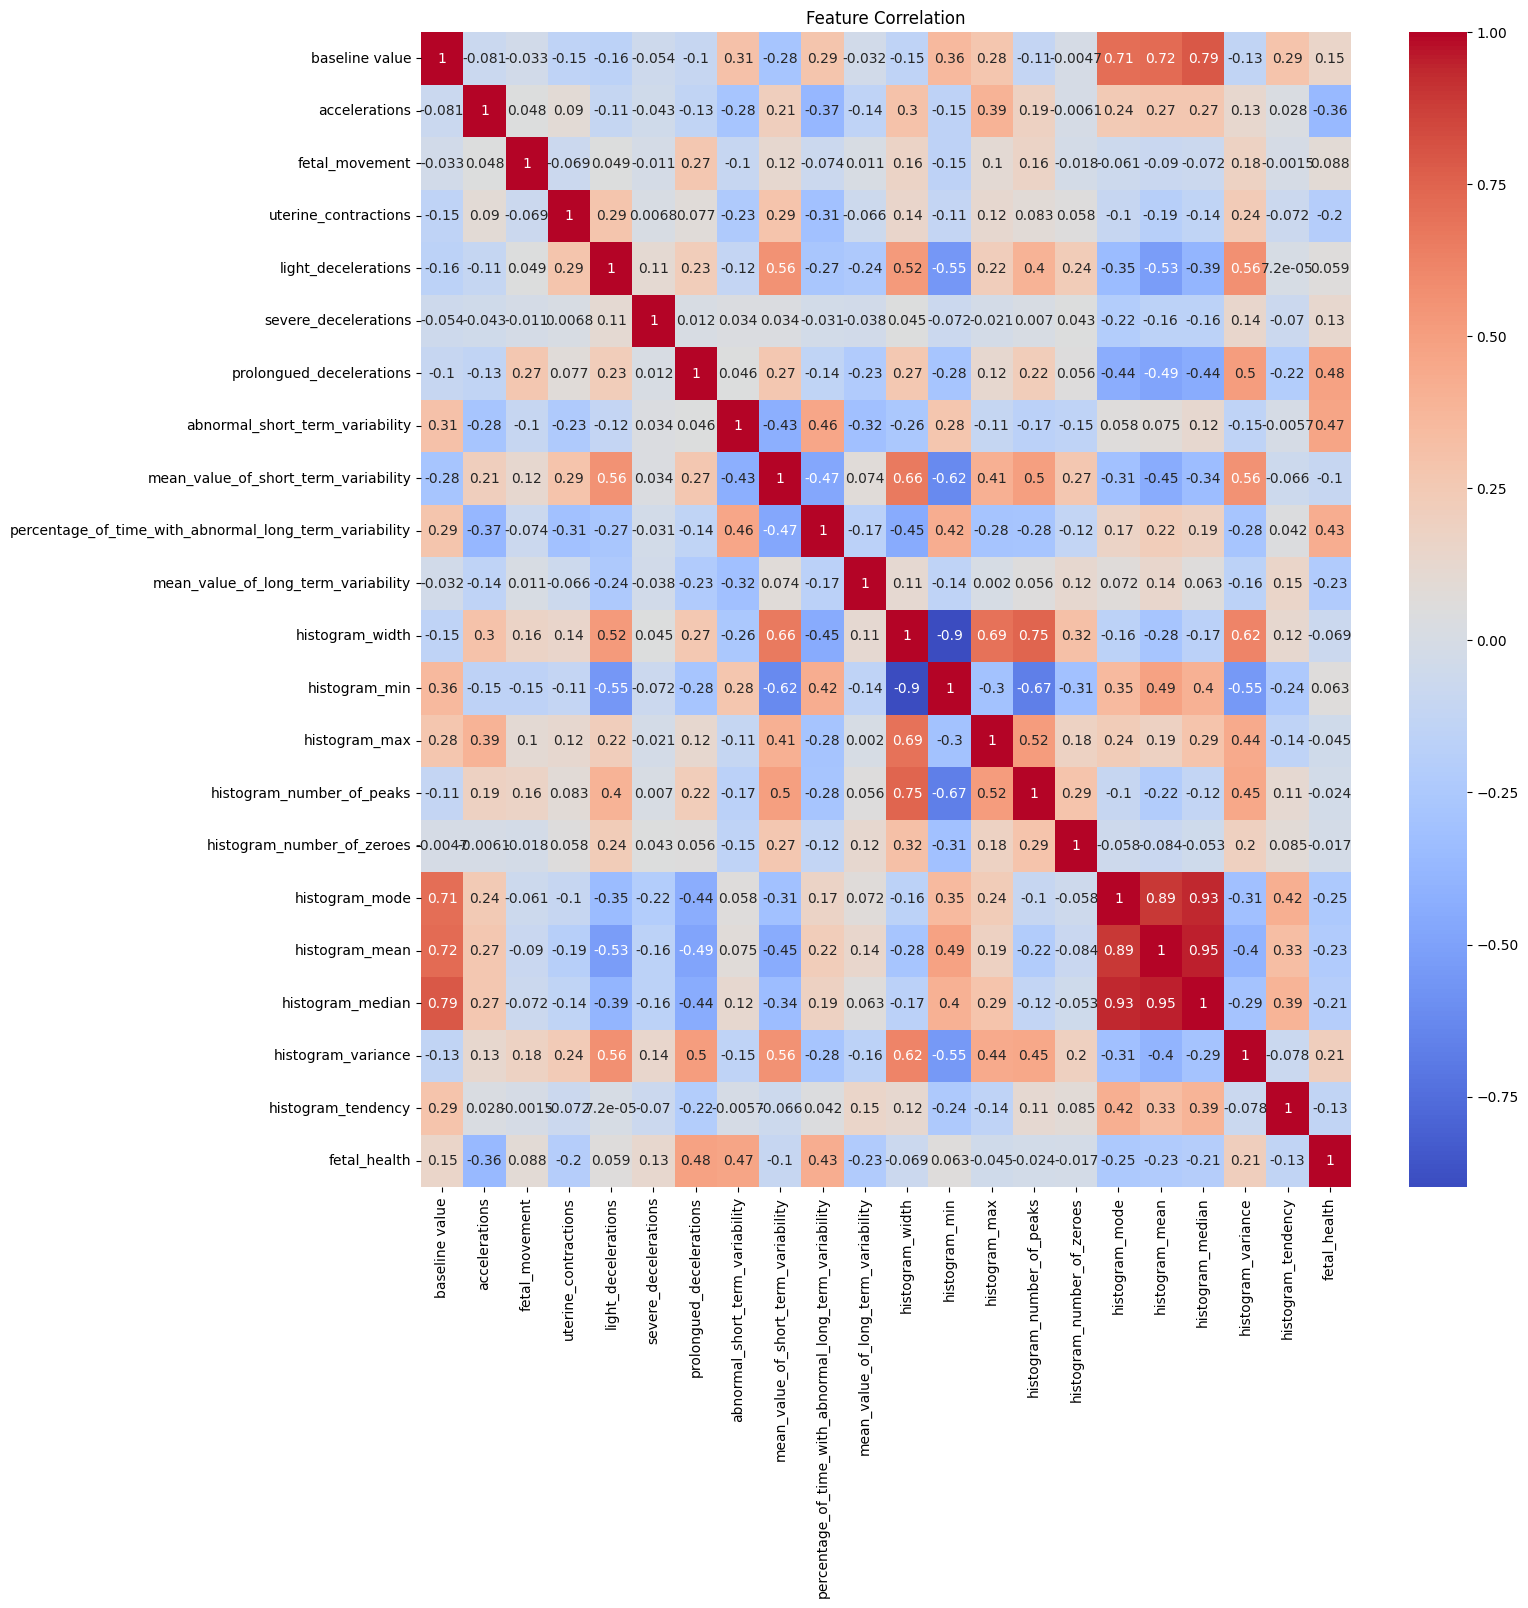

In [6]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

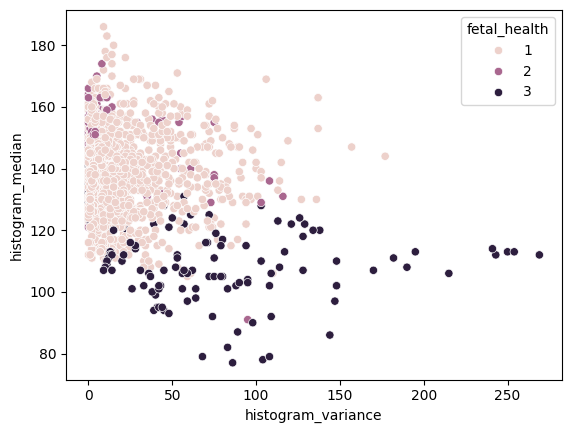

In [7]:
sns.scatterplot(
    x='histogram_variance',
    y='histogram_median',
    hue='fetal_health',
    data=df
)
plt.show()

**Feature Selection**

In [8]:
selected_features = [
    'prolongued_decelerations',
    'abnormal_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability',
    'histogram_variance',
    'histogram_median',
    'mean_value_of_long_term_variability',
    'histogram_mode',
    'accelerations'
]
X = df[selected_features]
y = df['fetal_health']

**Scaling dataset**

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

**Train-Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT for imbalance
)

**Handling Imbalance dataset**

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

**Model Training**

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    )
}


**Model testing**

In [15]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

results = {}
trained_models = {}
y_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test)
    y_predictions[name] = y_pred

    acc = accuracy_score(y_test, y_predictions[name])
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8099
Decision Tree Accuracy: 0.8897
KNN Accuracy: 0.9014
Random Forest Accuracy: 0.9131


**Model Prediction**

In [22]:
from sklearn.metrics import classification_report

for name in y_predictions:
    print(f"\n📊 {name} Classification Report")
    print(classification_report(y_test, y_predictions[name]))


📊 Logistic Regression Classification Report
              precision    recall  f1-score   support

           1       0.97      0.82      0.89       332
           2       0.43      0.80      0.56        59
           3       0.71      0.77      0.74        35

    accuracy                           0.81       426
   macro avg       0.70      0.79      0.73       426
weighted avg       0.88      0.81      0.83       426


📊 Decision Tree Classification Report
              precision    recall  f1-score   support

           1       0.95      0.93      0.94       332
           2       0.64      0.71      0.67        59
           3       0.81      0.83      0.82        35

    accuracy                           0.89       426
   macro avg       0.80      0.82      0.81       426
weighted avg       0.90      0.89      0.89       426


📊 KNN Classification Report
              precision    recall  f1-score   support

           1       0.98      0.92      0.95       332
           2    

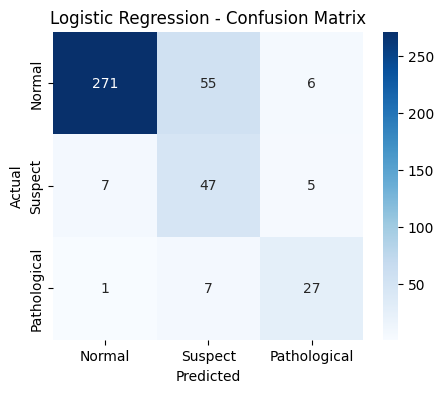

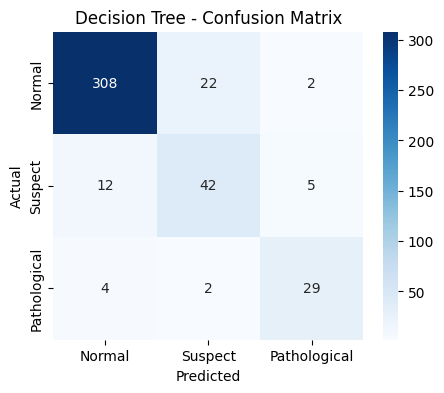

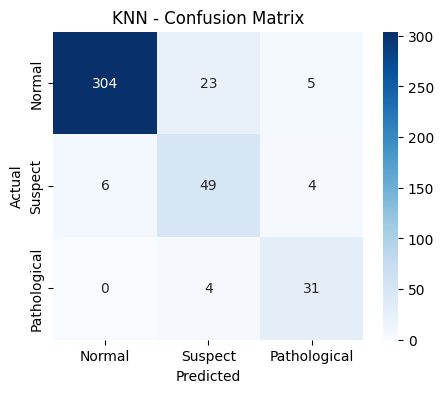

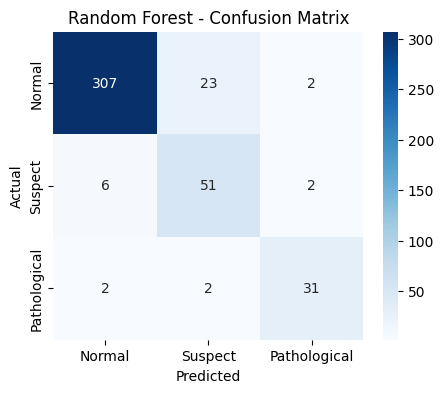

In [24]:
labels = ["Normal", "Suspect", "Pathological"]

for name, y_pred in y_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

**Model Saving**

In [25]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [26]:
import pickle

pickle.dump((model, scaler), open("fetal_health.pkl", "wb"))
print("Best model saved successfully!")

Best model saved successfully!


**Inference code**

In [27]:
import pandas as pd
import pickle

model, scaler = pickle.load(open("fetal_health.pkl","rb"))

# Create DataFrame with SAME column names
sample_df = pd.DataFrame([{
    'prolongued_decelerations': 0.0,
    'abnormal_short_term_variability': 20,
    'percentage_of_time_with_abnormal_long_term_variability': 10,
    'histogram_variance': 20,
    'histogram_median': 120,
    'mean_value_of_long_term_variability': 10,
    'histogram_mode': 120,
    'accelerations': 0.005
}])

# Scale
sample_scaled = scaler.transform(sample_df)

# Predict
prediction = model.predict(sample_scaled)

print(prediction)

[1]
